### Unsupervised Learning

##### Eucledian Distance

AC^2 = AB^2 + BC^2

AC = sqrt(AB^2 + BC^2)

AC = sqrt((x2-x1)^2 + (y2-y1)^2)

##### Manhattan Distance

AC = |AB| + |BC|

AC = |x2-x1| + |y2-y1|

### K Means

Initialize k centroids (let k be a random value)

Now calculate the distance (Eucledian or Manhattan) between data points to the k centroids

Now divide the data points into k clusters based on the above calculated distances

Now compute the centroid of each cluster

Now again calculate the distance between the data points to these new centroids and repeat the above process

Repeat it until the centroids doesn't change

Now repeat the entire process for different k values

The distance between the data points and centroids is called as **Within Cluster Sum of Squares (WCSS)** distance

Plot a graph between K value and WCSS

Choose K value using the elbow method

![](Elbow.png)

### Hierarchical Clustering

Consider each point as a single cluster

##### Dendogram

Points (X-axis) vs Distance (Y-axis)

We use **Eucledian distance** for Hierarchical Clustering

##### How to get the no. of clusters?

How many points are passing through the longest vertical line horizontally is the number of clusters

![](Dendogram.png)

### DBSCAN (Density Based Spatial Clustering of Applications with Noise)

Epsilon

Min points

Core points

Border points

Noise points

Let min_points & epsilon values are decided

epsilon is the radius

Choose every data point and draw a circle with radius epsilon

Within the circle of epsilon radius find at least >= min_points present inside the circle => Chosen point is **Core Point**

If min points inside circle of radius epsilon not equals to min_points but at least 1 core point is inside the boundary => Chosen point is **Boundary Point**

If min points inside circle of radius epsilon not equals to min_points and no core points available inside the boundary => Chosen point is **Noise Point**
                                                                                                                       
Noise Point is like an Outlier
                                                                                                                       
DBSCAN will not treat the Noise Points as a seperate cluster and they will skip noise points

##### Disadvantages:

Does not work well with clusters of similar density

Struggles with high dimensionality data

##### Advantages:

Great for seperating high density clusters

Great at handling outliers

In [1]:
dataset_link = 'https://raw.githubusercontent.com/krishnaik06/DBSCAN-Algorithm/refs/heads/master/Mall_Customers.csv'

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv(dataset_link)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.iloc[:,[-2,-1]].describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [5]:
X = df.iloc[:,[-2,-1]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
X.values[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]], dtype=int64)

In [8]:
X = X.values

In [16]:
X.shape

(200, 2)

In [9]:
from sklearn.cluster import DBSCAN

In [10]:
dbscan = DBSCAN(eps=3, min_samples=4)

In [11]:
model = dbscan.fit(X)

##### Unsupervised Learning

So no target column

In [12]:
labels = model.labels_

In [13]:
labels

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0,  0,
       -1,  0, -1, -1,  0, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  2,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  2,
        3,  3, -1,  3, -1, -1,  4, -1, -1, -1,  4,  5,  4, -1,  4,  5, -1,
        5,  4, -1,  4,  5, -1, -1,  6, -1, -1, -1,  7, -1,  6, -1,  6, -1,
        7, -1,  6, -1,  7, -1,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        8, -1,  8, -1,  8, -1,  8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], dtype=int64)

In [17]:
labels.shape

(200,)

##### Unique labels

In [15]:
set(labels)

{-1, 0, 1, 2, 3, 4, 5, 6, 7, 8}

In [18]:
sample_cores = np.zeros_like(labels, dtype=bool)

In [19]:
sample_cores.shape

(200,)

In [20]:
sample_cores

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [21]:
model.core_sample_indices_

array([ 58,  59,  62,  64,  66,  67,  69,  72,  74,  75,  76,  77,  78,
        80,  81,  83,  85,  87,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 119, 129, 131, 136, 137, 151, 153, 155, 170],
      dtype=int64)

In [23]:
sample_cores[model.core_sample_indices_] = True

In [24]:
sample_cores

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True, False, False,  True,
       False,  True, False,  True,  True, False,  True, False, False,
        True, False,  True,  True,  True,  True,  True, False,  True,
        True, False,  True, False,  True, False,  True, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False,  True, False, False, False, False, False, False,
       False, False,

#### Number of Clusters

In [25]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

In [26]:
n_clusters

9

In [27]:
print(silhouette_score(X, labels))

-0.1908319132560097


##### Plot the clusters

C:\Users\venka\AppData\Local\Temp\ipykernel_9592\1238366827.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(set(labels)))


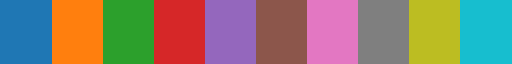

In [30]:
colors = plt.cm.get_cmap("tab10", len(set(labels)))
colors

In [32]:
X[labels==1]

array([[54, 47],
       [54, 54],
       [54, 53],
       [54, 48],
       [54, 52],
       [54, 42],
       [54, 51],
       [54, 55],
       [54, 41],
       [54, 44],
       [54, 57],
       [54, 46],
       [57, 58],
       [57, 55],
       [59, 55]], dtype=int64)

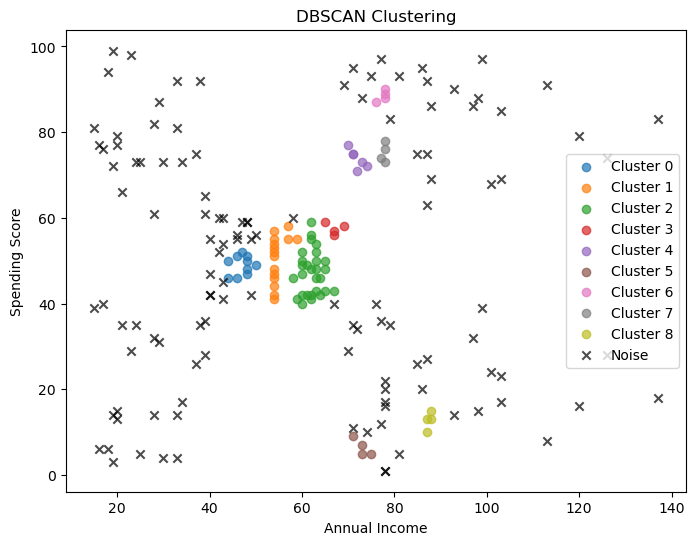

In [36]:
plt.figure(figsize=(8,6))
for label in set(labels):
    cluster_points = X[labels==label]
    if label == -1:
        plt.scatter(cluster_points[:,0], cluster_points[:,1], c="black", marker="x", label="Noise", alpha=0.7)
    else:
        plt.scatter(cluster_points[:,0], cluster_points[:,1], c=[colors(label)], label=f"Cluster {label}", alpha=0.7)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

### Validating Clustering Methods

##### Silhouette Clustering validation

Silhouette ranges from -1 to 1

A high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters

![](Silhouette.jpg)

![](Silhouette_Coeff.jpg)

### Performance Metrics for Clustering

##### Silhouette Coefficient

In [37]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [38]:
import matplotlib.cm as cm

##### Sample data

In [39]:
range_n_clusters = [2,3,4,5,6]

In [55]:
X,y = make_blobs(n_samples=500,
                n_features=2,
                centers=4,
                cluster_std=1,
                center_box=(-10,10),
                shuffle=True,
                random_state=1)

In [56]:
X.shape

(500, 2)

In [57]:
y.shape

(500,)

In [58]:
X[:5]

array([[ -6.92324165, -10.66953197],
       [ -8.63062033,  -7.13940564],
       [ -9.63048069,  -2.72044935],
       [ -2.30647659,   5.30797676],
       [ -7.57005366,  -3.01446491]])

#### K Means

In [59]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [60]:
wcss = []
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [61]:
wcss

[15767.55454617228,
 3735.4056749295637,
 1903.69794565734,
 908.3855684760615,
 835.6245005367675,
 752.7163094271172,
 706.8620113824743,
 578.7615453759137,
 524.8923635264923,
 504.41654711986456]

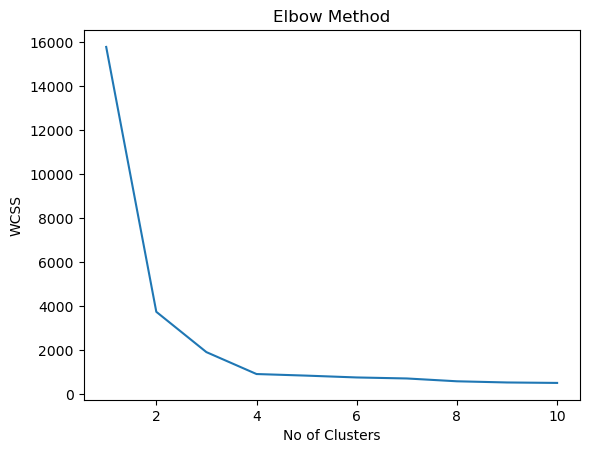

In [62]:
plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()

From the elbow method, it's clear that 4 clusters is good

Implement with 4 clusters

In [64]:
kMeans4 = KMeans(n_clusters=4, random_state=10)

In [65]:
kMeans4_labels = kMeans4.fit_predict(X)

In [66]:
kMeans4_labels

array([3, 3, 0, 1, 2, 1, 2, 2, 2, 2, 3, 3, 2, 1, 2, 3, 2, 3, 1, 2, 0, 0,
       2, 1, 2, 2, 1, 1, 0, 2, 3, 1, 2, 3, 2, 3, 0, 0, 3, 0, 2, 0, 1, 2,
       2, 3, 0, 2, 1, 1, 1, 0, 0, 2, 3, 0, 0, 0, 0, 2, 1, 1, 0, 2, 1, 2,
       3, 2, 0, 0, 3, 0, 2, 3, 2, 2, 3, 2, 2, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 3, 0, 2, 1, 3, 3, 2, 3, 1, 1, 3, 1, 0, 1, 2, 2, 1, 1, 0,
       2, 3, 1, 0, 1, 0, 1, 2, 1, 2, 0, 3, 3, 0, 2, 0, 1, 3, 3, 2, 1, 0,
       0, 0, 0, 3, 1, 2, 1, 1, 2, 3, 2, 1, 1, 1, 2, 2, 3, 3, 0, 0, 1, 3,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 2, 1, 3, 0, 2, 3, 1, 0,
       0, 0, 0, 3, 2, 0, 1, 3, 3, 0, 2, 3, 3, 2, 1, 1, 3, 3, 2, 1, 2, 3,
       3, 1, 3, 0, 1, 2, 2, 3, 2, 0, 3, 2, 0, 2, 0, 3, 2, 2, 2, 1, 0, 1,
       2, 3, 0, 2, 0, 0, 0, 1, 0, 1, 3, 0, 3, 0, 1, 1, 0, 3, 1, 3, 2, 0,
       3, 3, 3, 3, 2, 0, 3, 0, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 0,
       1, 2, 3, 3, 0, 0, 0, 2, 1, 1, 2, 1, 0, 3, 1, 3, 1, 3, 3, 1, 3, 1,
       1, 2, 0, 0, 0, 2, 2, 0, 3, 1, 3, 3, 3, 2, 0,

In [69]:
silhouette_score(X, kMeans4_labels)

0.6505186632729437

In [71]:
len(silhouette_samples(X, kMeans4_labels))

500

In [72]:
silhouette_samples(X, kMeans4_labels).shape

(500,)

In [73]:
silhouette_samples(X, kMeans4_labels)[:5]

array([0.62903385, 0.43289576, 0.55834047, 0.82660742, 0.35213124])

In [80]:
silhouette_samples(X, kMeans4_labels)[kMeans4_labels==3]

array([0.62903385, 0.43289576, 0.59363669, 0.75135825, 0.59477448,
       0.66633309, 0.62490578, 0.54405603, 0.6694404 , 0.58315885,
       0.73163465, 0.63576372, 0.69778864, 0.64892594, 0.69871837,
       0.75328423, 0.57351761, 0.72152963, 0.63168005, 0.55911976,
       0.69469544, 0.75276236, 0.52750486, 0.66904087, 0.76006921,
       0.69263105, 0.56363829, 0.50564715, 0.49825455, 0.59695559,
       0.74785868, 0.35221048, 0.73508598, 0.61363209, 0.62568743,
       0.60301291, 0.55269651, 0.43934625, 0.72193903, 0.74909326,
       0.72291783, 0.66126514, 0.31716798, 0.65706799, 0.73981774,
       0.72526562, 0.62489594, 0.75229552, 0.73004638, 0.71475664,
       0.69250151, 0.67373235, 0.72000523, 0.62338775, 0.7328447 ,
       0.74837575, 0.73431429, 0.58679954, 0.62101494, 0.68323288,
       0.72043564, 0.53064417, 0.68329404, 0.71466842, 0.73795813,
       0.67953558, 0.42187352, 0.51837   , 0.05555848, 0.55040536,
       0.67263151, 0.50693326, 0.54230967, 0.67691214, 0.49587

In [81]:
len(silhouette_samples(X, kMeans4_labels)[kMeans4_labels==3])

124

In [86]:
silhouette_samples(X, kMeans4_labels)[kMeans4_labels==3].sort()

In [89]:
test = silhouette_samples(X, kMeans4_labels)[kMeans4_labels==3]

In [91]:
test.sort()

In [92]:
test

array([0.05555848, 0.31716798, 0.35175708, 0.35221048, 0.39793802,
       0.40598262, 0.41095767, 0.41590615, 0.42187352, 0.43289576,
       0.43934625, 0.49205564, 0.49587889, 0.49825455, 0.50564715,
       0.50693326, 0.51456386, 0.51837   , 0.52551701, 0.52750486,
       0.53064417, 0.54230967, 0.54405603, 0.55040536, 0.55269651,
       0.55911976, 0.56363829, 0.57351761, 0.58315885, 0.58679954,
       0.59363669, 0.59477448, 0.59695559, 0.6013632 , 0.60301291,
       0.6040488 , 0.61156042, 0.61251082, 0.61363209, 0.61689676,
       0.6190129 , 0.62012949, 0.62101494, 0.62206789, 0.62338775,
       0.62489594, 0.62490578, 0.62568743, 0.62903385, 0.63168005,
       0.63576372, 0.63621001, 0.63874743, 0.63921141, 0.64892594,
       0.65473612, 0.65706799, 0.66126514, 0.66412442, 0.66633309,
       0.66904087, 0.6694404 , 0.67263151, 0.67331687, 0.67373235,
       0.67546489, 0.67593127, 0.67595374, 0.6764497 , 0.67691214,
       0.67953558, 0.68292808, 0.68323288, 0.68329404, 0.68960

In [95]:
silhouette_samples(X, kMeans4_labels)[kMeans4_labels==3].shape

(124,)

In [96]:
kMeans4.cluster_centers_

array([[-10.00969056,  -3.84944007],
       [ -1.54234022,   4.43517599],
       [ -6.08459039,  -3.17305983],
       [ -7.09306648,  -8.10994454]])

##### Now let's validate whether the cluster 4 is correct or not

In [67]:
range_n_clusters

[2, 3, 4, 5, 6]

In [68]:
len(X)

500

For n_clusters = 2 The average silhouette_score is: 0.7049787496083262
For n_clusters = 3 The average silhouette_score is: 0.5882004012129721
For n_clusters = 4 The average silhouette_score is: 0.6505186632729437
For n_clusters = 5 The average silhouette_score is: 0.561464362648773
For n_clusters = 6 The average silhouette_score is: 0.4857596147013469


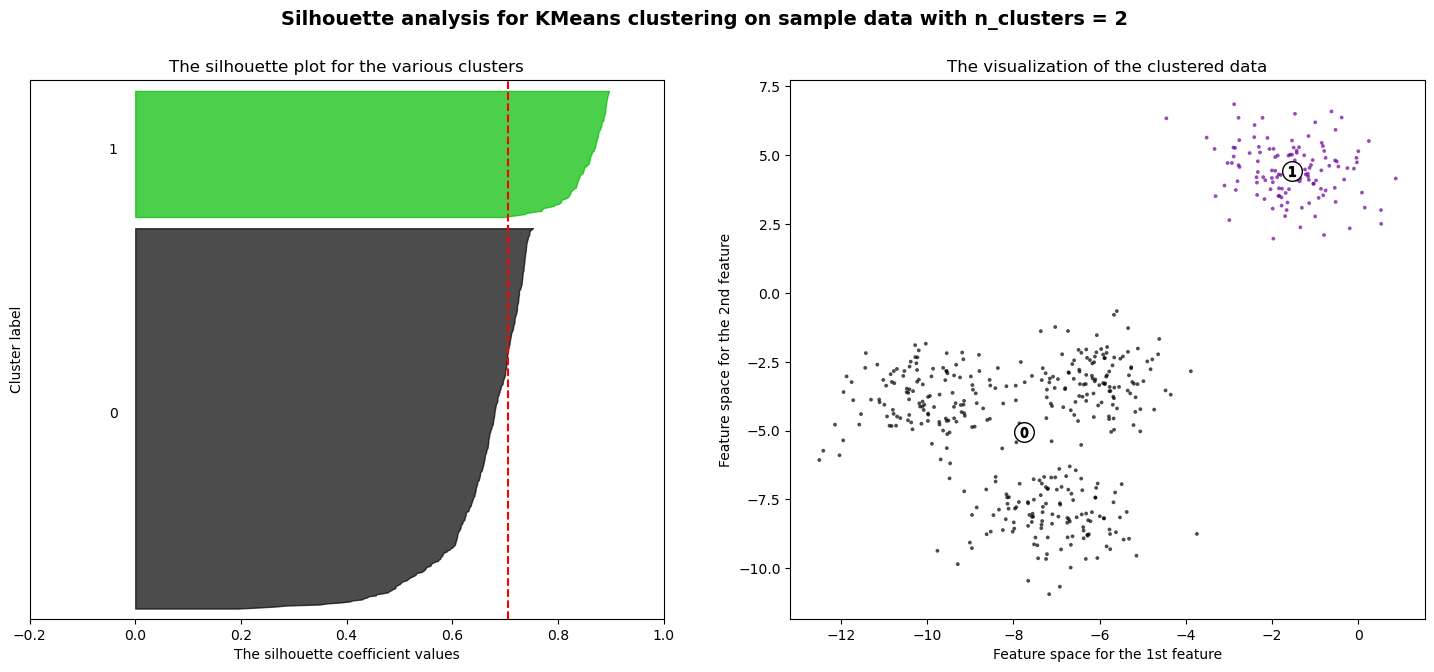

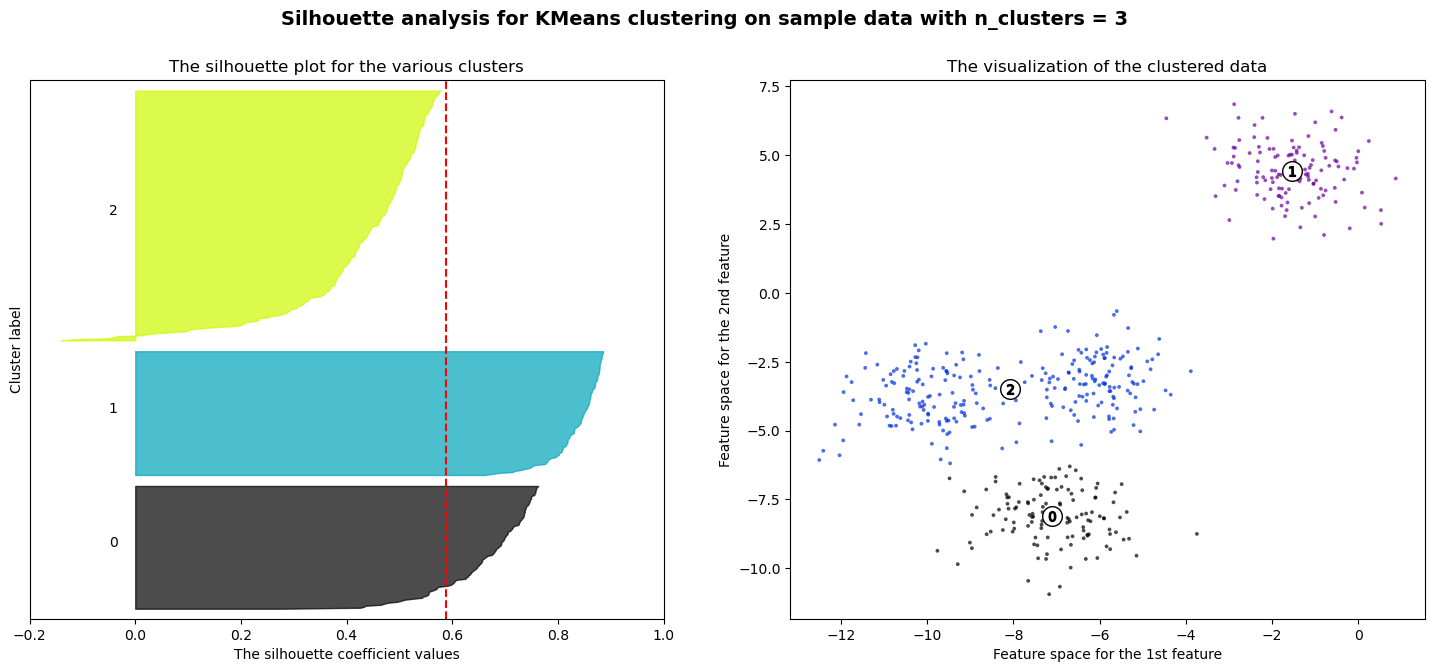

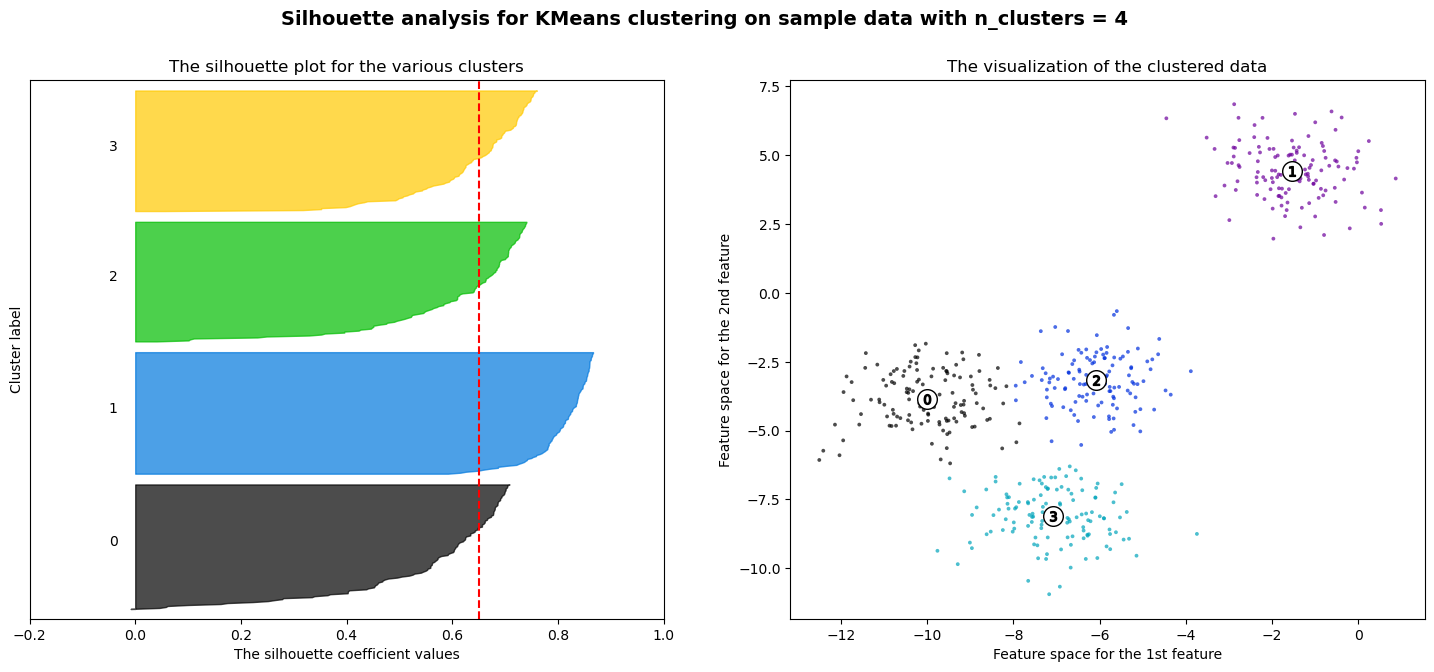

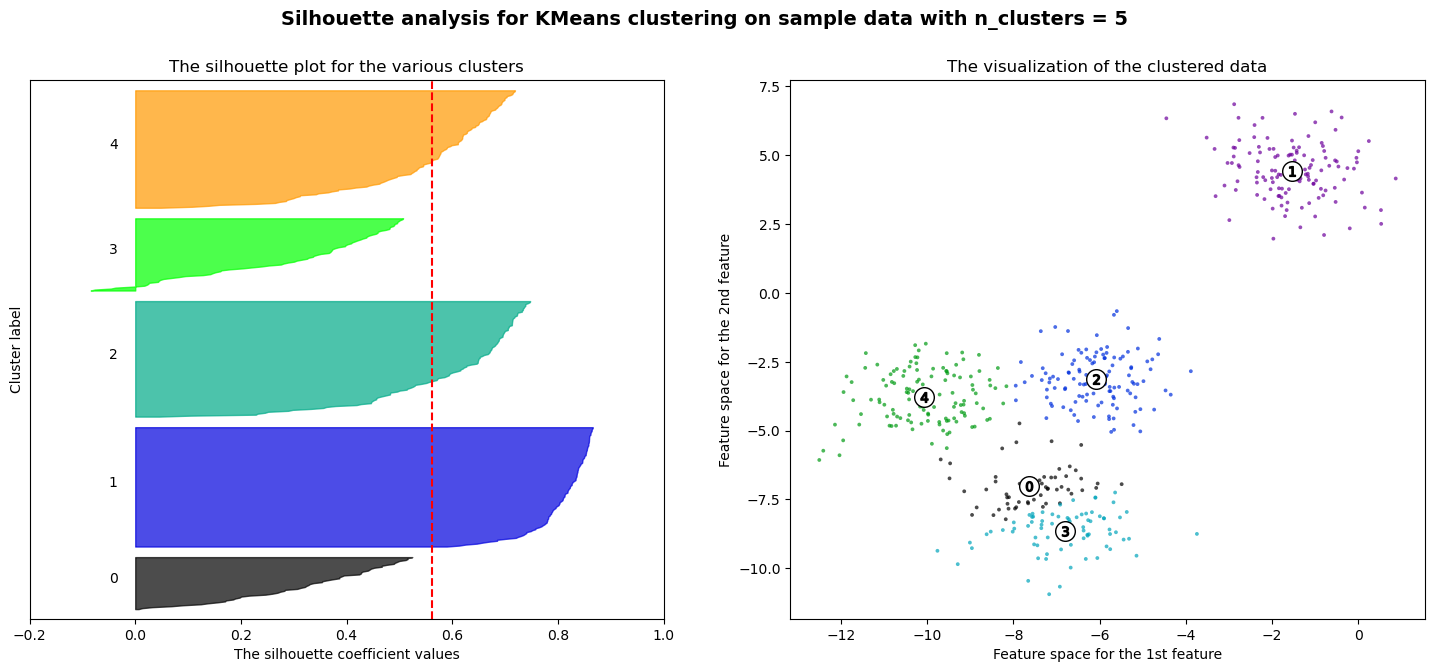

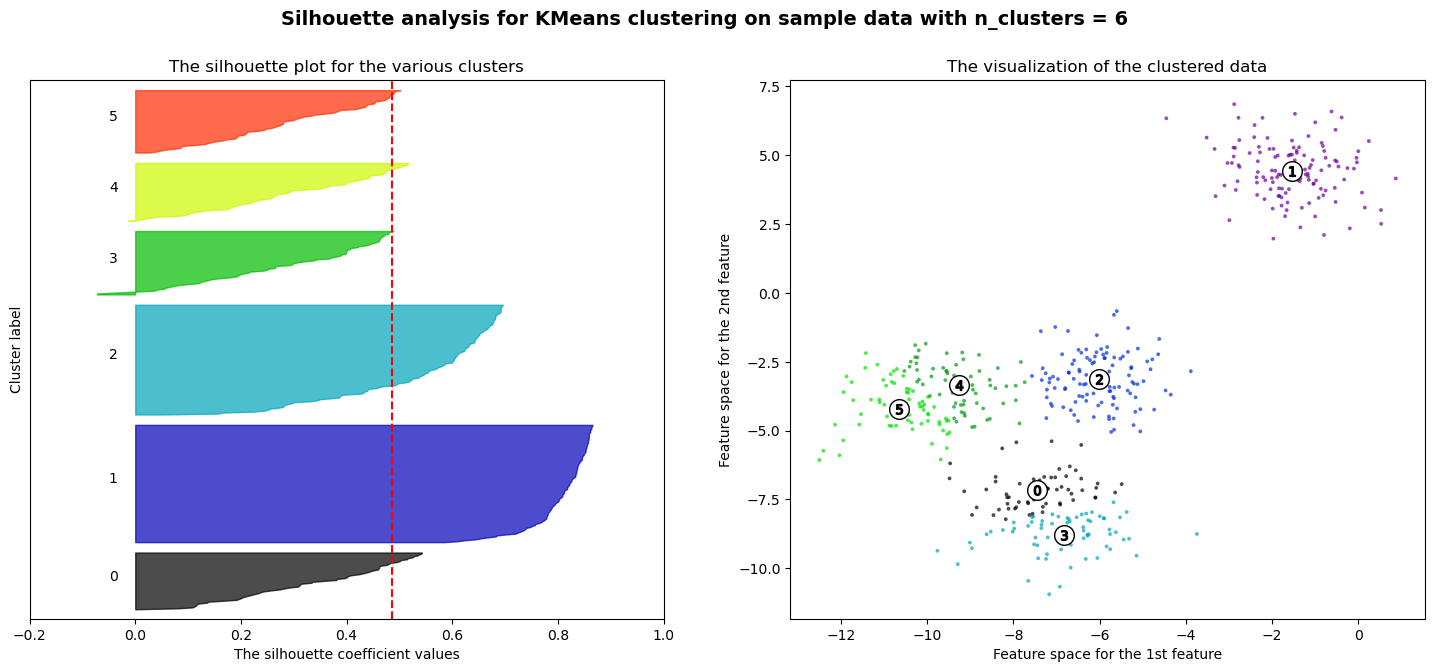

In [102]:
for cluster in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1,2) # 1 row & 2 columns
    fig.set_size_inches(18,7)

    ax1.set_xlim([-0.1,1])
    ax1.set_ylim([0,len(X)+(cluster+1)*10]) # for inserting blank space b/w plots of individual clusters

    kMeansCluster = KMeans(n_clusters=cluster, random_state=10)
    cluster_labels = kMeansCluster.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels) # average silhouette score for all samples
    print(f"For n_clusters = {cluster} The average silhouette_score is: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X, cluster_labels) # silhouette scores for each sample

    y_lower = 10
    for i in range(cluster):
        ith_cluster_silhouette_vals = sample_silhouette_values[cluster_labels==i]
        ith_cluster_silhouette_vals.sort()

        size_cluster_i = len(ith_cluster_silhouette_vals)
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i)/cluster)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_cluster_silhouette_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5*size_cluster_i, str(i)) # label silhouette plots with cluster numbers at the middle

        y_lower = y_upper + 10 # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])
    ax1.set_xticks([-0.2,0,0.2,0.4,0.6,0.8,1])

    colors = cm.nipy_spectral(cluster_labels.astype(float)/n_clusters)
    ax2.scatter(X[:,0], X[:,1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k")

    centers = kMeansCluster.cluster_centers_
    ax2.scatter(centers[:,0], centers[:,1], marker="o", c="white", alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")
    ax2.set_title("The visualization of the clustered data")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {cluster}", fontsize=14, fontweight="bold")

plt.show()

Thus the one with 4 clusters have a very good silhouette plot